In [3]:
import statsmodels.api as sm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../../Datasets/house_price_dataset_original_v2_with_categorical_features.csv")
df.head(5)

,land_size_sqm,house_size_sqm,no_of_rooms,no_of_bathrooms,large_living_room,parking_space,front_garden,swimming_pool,distance_to_school,wall_fence,house_age,water_front,distance_to_supermarket,crime_rate_index,room_size,property_value
0,201 sqm,177 sqm,3,1,No,Yes,Yes,No,3.3km,Yes,10 Years,No,6.8 km,0.90,small,165432
1,196 sqm,182 sqm,4,3,Yes,Yes,No,Yes,1.2km,Yes,11 Years,No,4.1 km,1.42,medium,187043
2,198 sqm,182 sqm,4,4,Yes,Yes,No,Yes,5.9km,No,20 Years,No,2.1 km,4.12,medium,148658
3,178 sqm,166 sqm,2,3,No,Yes,No,No,5.9km,No,5 Years,No,0.7 km,4.36,small,123785
4,183 sqm,165 sqm,3,1,Yes,Yes,No,No,3.8km,Yes,8 Years,No,0.7 km,0.42,small,156470


### Step 2a: Distributions & imbalances


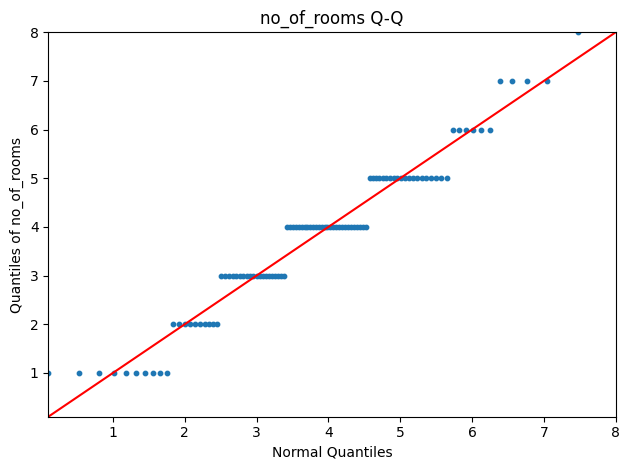

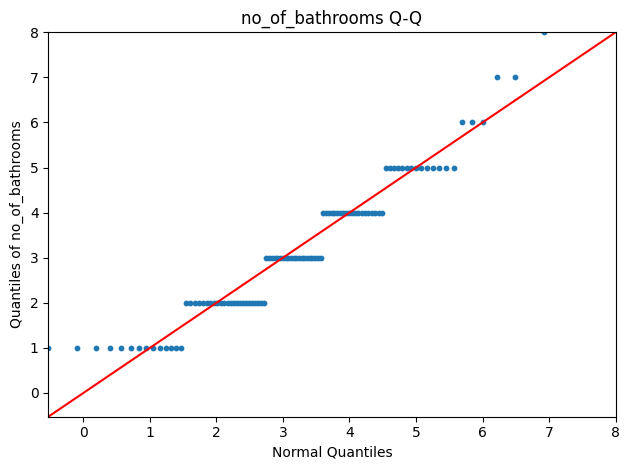

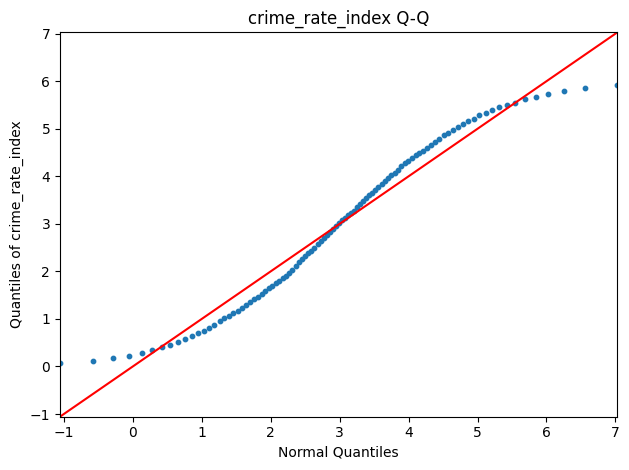

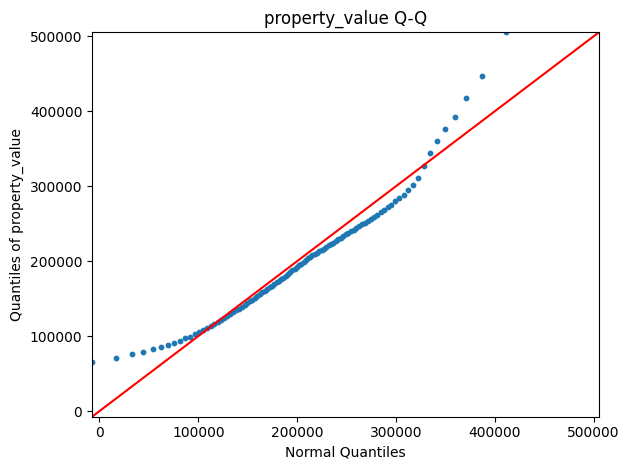

In [2]:
# This snippet displays the Q-Q plots for each numeric column!

import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt

for column in df.columns:

    # Get rid of any non-numerical columns.
    if pd.api.types.is_numeric_dtype(df[column]):

        # Drop missing values in case it causes problems
        values = df[column].dropna()

        # Fit a normal distribution to THIS column's own scale.
        mean, std = values.mean(), values.std()

        # Make 99 percentiles, evenly spaced.
        probs = np.linspace(0.01, 0.99, 99)

        # Copies dataprep's method. take the sample of the quantiles.
        sample_qntls = values.quantile(probs)

        # Theoretical quantiles: what a perfectly normal distribution with
        # the datas mean and std would look like at each %
        theory_qntls = norm.ppf(probs, mean, std)

        # Combine both sets to find a shared min/max.
        vals = np.concatenate([sample_qntls, theory_qntls])
        lo, hi = vals.min(), vals.max()
        fig, ax = plt.subplots()

        # Plot sample quantiles with theoretical quantiles.
        ax.scatter(theory_qntls, sample_qntls, s=10)

        # Draw a diagonal line.
        ax.plot([lo, hi], [lo, hi], color="r")

        # Force both axes to the same range. Makes the 45 degrees fixed.
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)

        ax.set_title(f"{column} Q-Q")
        ax.set_xlabel("Normal Quantiles")
        ax.set_ylabel(f"Quantiles of {column}")

        plt.tight_layout()
        plt.show()

#### Step 2b: Multicollinearity & redundancy

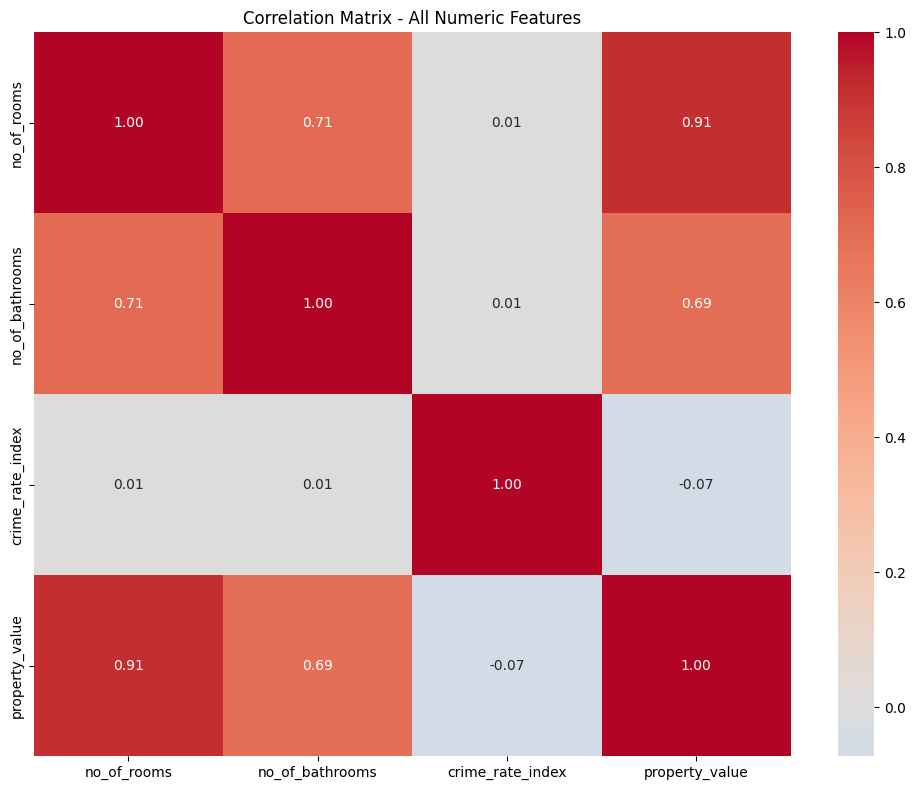

In [ ]:
# Checking the correlation between all numeric features in the dataset.
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', center=0)
plt.title('Correlation Matrix - All Numeric Features')
plt.tight_layout()
plt.show()

##### VIF-test to test multicollinearity (~redundancy)

In [8]:

# pip install statsmodels
from statsmodels.stats.outliers_influence import variance_inflation_factor 
import pandas as pd

pd.set_option('display.float_format', lambda x: '%.1f' % x) 

import warnings
warnings.filterwarnings("ignore")

# load the data
df = pd.read_csv("../../Datasets/cleaned_house_data.csv")

# handle these better with your own dataset, here we are simply dropping these
# df = df.drop(['id', 'date', 'zipcode', 'lat', 'long'], axis=1)

# perform X/y -split
# if you  have more than one independent variable, list them all here
# leave out the target variable! (dependent variable)

# this is a nice and common trick => everything EXCEPT target variable => support variable
X = df.drop("property_value", axis=1)

# have only the target variable here (dependent variable)
y = df["property_value"]


# VIF dataframe 
# VIF = Variance Inflation Factor
vif_data = pd.DataFrame() 
vif_data["feature"] = X.columns 
  
# calculating VIF for each feature 
vif_data["VIF"] = [variance_inflation_factor(X.values, i) 
                          for i in range(len(X.columns))] 

# variables with high VIF-value 
# can mean multlicollinearity (variables providing same linear
# relationships in the data, potentially confusing the ML algorithm
# this might be good info when deciding if some variable needs to be removed
vif_data.sort_values(by="VIF", ascending=False)

,feature,VIF
0,land_size_sqm,64.1
1,house_size_sqm,62.1
2,no_of_rooms,9.5
3,no_of_bathrooms,2.1
7,swimming_pool,1.7
6,front_garden,1.6
9,wall_fence,1.5
5,parking_space,1.4
4,large_living_room,1.3
14,room_size,1.2


#### Let's check what happens to VIF score by droping land and house size alternatively to check if the score drops to healthy level

In [ ]:
# Took help of Claude to write the below code snippet
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings("ignore")

numeric_cols = ['land_size_sqm', 'house_size_sqm', 'no_of_rooms', 'no_of_bathrooms',
                 'distance_to_school', 'house_age', 'distance_to_supermarket', 'crime_rate_index']

# helper function so we don't repeat the same VIF code 3 times
def run_vif(cols, label):
    X = df[cols]
    vif_data = pd.DataFrame()
    vif_data["feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(len(X.columns))]
    print(f"=== {label} ===")
    print(vif_data.sort_values(by="VIF", ascending=False).to_string(index=False))
    print()

# 1. Baseline — all 8 numeric features together
run_vif(numeric_cols, "Baseline (all 8 numeric features)")

# 2. Drop land_size_sqm, recheck VIF of the rest
cols_no_land = [c for c in numeric_cols if c != 'land_size_sqm']
run_vif(cols_no_land, "After dropping land_size_sqm")

# 3. Drop house_size_sqm instead, recheck VIF of the rest (for comparison)
cols_no_house = [c for c in numeric_cols if c != 'house_size_sqm']
run_vif(cols_no_house, "After dropping house_size_sqm (alt.)")

=== Baseline (all 8 numeric features) ===
                feature  VIF
          land_size_sqm 60.5
         house_size_sqm 58.6
            no_of_rooms  5.8
        no_of_bathrooms  2.1
distance_to_supermarket  1.0
       crime_rate_index  1.0
     distance_to_school  1.0
              house_age  1.0

=== After dropping land_size_sqm ===
                feature  VIF
            no_of_rooms  5.6
         house_size_sqm  5.1
        no_of_bathrooms  2.1
distance_to_supermarket  1.0
       crime_rate_index  1.0
     distance_to_school  1.0
              house_age  1.0

=== After dropping house_size_sqm (alt.) ===
                feature  VIF
            no_of_rooms  5.7
          land_size_sqm  5.3
        no_of_bathrooms  2.1
distance_to_supermarket  1.0
       crime_rate_index  1.0
     distance_to_school  1.0
              house_age  1.0



### Step 2c: High cardinality

In [ ]:
# Checking the number of unique values in categorical columns
cat_cols = ['large_living_room','parking_space','front_garden','swimming_pool',
            'wall_fence','water_front','room_size']
for col in cat_cols:
    print(col, df[col].nunique())

large_living_room 2
parking_space 2
front_garden 2
swimming_pool 2
wall_fence 2
water_front 2
room_size 4
